# 📊 RAG-for-LAW — Đánh Giá Toàn Diện Hệ Thống

**Notebook này đánh giá hệ thống RAG pháp lý tiếng Việt theo các metrics chuẩn từ các bài báo nổi tiếng:**

| Metrics | Nguồn |  
|---|---|
| Hit Rate@K, MRR, NDCG@K | Manning et al. (2008) *Introduction to Information Retrieval*; TREC Evaluation |
| Faithfulness, Answer Relevancy, Context Recall | **RAGAS** – Es et al. (2023) *RAGAS: Automated Evaluation of Retrieval Augmented Generation* |
| LLM-as-Judge | **G-Eval** – Liu et al. (2023) *G-EVAL: NLG Evaluation using GPT-4 with Better Human Alignment* |
| HyDE + Metadata-aware Retrieval | **HyDE** – Gao et al. (2022) *Precise Zero-Shot Dense Retrieval without Relevance Labels* |
| Lost-in-the-Middle Analysis | Liu et al. (2023) *Lost in the Middle: How Language Models Use Long Contexts* |
| Token Budget & Efficiency | Kovcisky et al. (2018); pratical RAG engineering |

---
**Pipeline so sánh:**
- 🔵 **Basic RAG** (`use_think=False`): Vector search top-3 → Generate
- 🟢 **Advanced RAG** (`use_think=True`): HyDE + Metadata → Vector search top-20 → Cross-Encoder Rerank → Token Budget → Lost-in-Middle → Generate


## 📦 Section 0: Setup & Configuration

In [1]:
# === CONFIGURATION ===
# Số câu chạy mỗi pipeline (None = toàn bộ)
EVAL_SAMPLE_SIZE = None   # Đặt là 50 để test nhanh, None để chạy full 300

# Chế độ chạy
RUN_BASIC    = True   # Chạy Basic pipeline
RUN_ADVANCED = True   # Chạy Advanced pipeline  

# Thư mục lưu kết quả
OUTPUT_DIR = "./eval_results"

# Metrics thresholds
FAITHFULNESS_THRESHOLD = 0.5  # Điểm faithfulness tối thiểu để PASS
RELEVANCY_THRESHOLD    = 0.5  # Điểm relevancy tối thiểu để PASS

print("✅ Configuration loaded.")
print(f"   EVAL_SAMPLE_SIZE : {EVAL_SAMPLE_SIZE if EVAL_SAMPLE_SIZE else 'ALL (300 câu)'}")
print(f"   RUN_BASIC        : {RUN_BASIC}")
print(f"   RUN_ADVANCED     : {RUN_ADVANCED}")

✅ Configuration loaded.
   EVAL_SAMPLE_SIZE : ALL (300 câu)
   RUN_BASIC        : True
   RUN_ADVANCED     : True


In [2]:
import os
import json
import time
import math
import warnings
import re
from typing import List, Dict, Any, Optional
from datetime import datetime
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Matplotlib style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0d1117',
    'axes.facecolor'    : '#161b22',
    'axes.edgecolor'    : '#30363d',
    'axes.labelcolor'   : '#e6edf3',
    'xtick.color'       : '#8b949e',
    'ytick.color'       : '#8b949e',
    'text.color'        : '#e6edf3',
    'grid.color'        : '#21262d',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.6,
    'legend.facecolor'  : '#161b22',
    'legend.edgecolor'  : '#30363d',
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
})

# Colour palette
BLUE   = '#58a6ff'   # Basic RAG
GREEN  = '#3fb950'   # Advanced RAG
ORANGE = '#d29922'
RED    = '#f85149'
PURPLE = '#a371f7'
TEAL   = '#39d353'

# ── Output dir ────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Imports done.")

✅ Imports done.


In [3]:
# Load RAG system
import sys
sys.path.insert(0, '.')

from llm_handler import app_graph, llm, strip_think_tags
from retrieval_handler import retriever
import config

print(f"✅ RAG system loaded. Model: {config.GROQ_MODEL_NAME}")
print(f"   ChromaDB: {config.CHROMADB_PERSIST_DIRECTORY}")
print(f"   Collection: {config.COLLECTION_NAME}")
print(f"   Reranker: {config.RERANKER_MODEL_PATH}")

[RetrievalHandler] Loading embedding model...
[RetrievalHandler] Embedding model loaded.
Loading Reranker Model...
Reranker Model Loaded.
✅ RAG system loaded. Model: meta-llama/llama-4-scout-17b-16e-instruct
   ChromaDB: ./chroma_db
   Collection: legal_documents
   Reranker: BAAI/bge-reranker-v2-m3


In [4]:
# ── Load Evaluation Dataset ───────────────────────────────────
with open('eval_dataset.json', 'r', encoding='utf-8') as f:
    eval_data_raw = json.load(f)

# Sampling if needed
if EVAL_SAMPLE_SIZE and EVAL_SAMPLE_SIZE < len(eval_data_raw):
    import random
    random.seed(42)
    eval_data = random.sample(eval_data_raw, EVAL_SAMPLE_SIZE)
    print(f"✅ Sampled {EVAL_SAMPLE_SIZE} / {len(eval_data_raw)} câu.")
else:
    eval_data = eval_data_raw
    print(f"✅ Loaded full dataset: {len(eval_data)} câu.")

# Dataset statistics
df_eval = pd.DataFrame(eval_data)
print(f"\n📊 Dataset overview:")
print(f"   Task types  : {df_eval['task_type'].nunique()} loại")
print(f"   Categories  : {df_eval['category'].nunique()} loại")
print(f"   Difficulties: {sorted(df_eval['difficulty'].unique())}")
print("\nPhân bố task_type:")
print(df_eval['task_type'].value_counts().to_string())

✅ Loaded full dataset: 200 câu.

📊 Dataset overview:
   Task types  : 10 loại
   Categories  : 10 loại
   Difficulties: ['easy', 'hard', 'medium']

Phân bố task_type:
task_type
summary             25
how                 25
common_reasoning    25
what                25
yes_no              20
legal_syllogism     20
listing             20
diverse             15
NLI                 15
where               10


## 🔧 Section 1: Định nghĩa Metrics & Helper Functions

> Theo **Manning et al. (2008)** và **RAGAS (Es et al., 2023)**

In [5]:
# ══════════════════════════════════════════════════════════════
# 1.1  RETRIEVAL METRICS
# Nguồn: Manning, Raghavan & Schütze (2008)
#        Introduction to Information Retrieval
# ══════════════════════════════════════════════════════════════

def check_metadata_match(retrieved_docs: List[dict], hint: dict) -> List[bool]:
    """
    Kiểm tra từng doc có match với metadata_hint không.
    Match khi sign_number trùng (nếu có) hoặc issuing_agency trùng.
    Dùng như ground-truth label cho retrieval (khi không có annotated relevance).
    """
    sign   = hint.get('sign_number', '').strip().lower()
    agency = hint.get('issuing_agency', '').strip().lower()
    
    matches = []
    for doc in retrieved_docs:
        meta = doc.get('metadata', {})
        doc_sign   = str(meta.get('sign_number', '')).strip().lower()
        doc_agency = str(meta.get('issuing_agency', '')).strip().lower()
        
        # Ưu tiên match sign_number; nếu không có sign thì match agency
        if sign and doc_sign:
            matched = (sign in doc_sign) or (doc_sign in sign)
        elif agency and doc_agency:
            matched = (agency in doc_agency) or (doc_agency in agency)
        else:
            matched = False
        matches.append(matched)
    return matches


def hit_rate_at_k(matches: List[bool], k: int) -> float:
    """Hit Rate@K: 1 nếu có ít nhất 1 doc đúng trong top-K. (RAGAS 2023)"""
    return float(any(matches[:k]))


def reciprocal_rank(matches: List[bool]) -> float:
    """MRR: 1/(rank of first relevant doc). (TREC; Manning 2008, Ch.8)"""
    for i, m in enumerate(matches):
        if m:
            return 1.0 / (i + 1)
    return 0.0


def ndcg_at_k(matches: List[bool], k: int) -> float:
    """
    NDCG@K – Normalized Discounted Cumulative Gain.
    (Järvelin & Kekäläinen, 2002; Manning 2008)
    Giả định binary relevance (0/1).
    """
    dcg  = sum(m / math.log2(i + 2) for i, m in enumerate(matches[:k]))
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(sum(matches), k)))
    return dcg / idcg if idcg > 0 else 0.0


def precision_at_k(matches: List[bool], k: int) -> float:
    """Precision@K: tỷ lệ doc đúng trong top-K."""
    top_k = matches[:k]
    return sum(top_k) / k if k > 0 else 0.0


print("✅ Retrieval metric functions defined.")

✅ Retrieval metric functions defined.


In [6]:
# ══════════════════════════════════════════════════════════════
# 1.2  GENERATION METRICS – LLM-as-Judge
# Nguồn: 
#   • RAGAS (Es et al., 2023) – faithfulness, answer_relevancy
#   • G-Eval (Liu et al., 2023) – GPT-4 based evaluation
# ══════════════════════════════════════════════════════════════

from langchain_core.messages import SystemMessage, HumanMessage

FAITHFULNESS_PROMPT = """Bạn là chuyên gia đánh giá chất lượng AI pháp lý.

Nhiệm vụ: Đánh giá mức độ TRUNG THỰC (Faithfulness) của câu trả lời dựa trên tài liệu tham chiếu.

Faithfulness = câu trả lời chỉ chứa thông tin từ context, không bịa đặt.

## Context (Tài liệu gốc):
{context}

## Câu hỏi:
{question}

## Câu trả lời của hệ thống:
{answer}

Chấm điểm theo thang 0.0–1.0:
- 1.0: Hoàn toàn trung thực, mọi thông tin đều có trong context
- 0.7: Phần lớn trung thực, có vài chi tiết nhỏ không rõ nguồn
- 0.5: Khoảng một nửa thông tin có thể xác minh từ context
- 0.3: Nhiều thông tin không có trong context (hallucination)
- 0.0: Hoàn toàn bịa đặt, không liên quan context

Trả lời ĐÚNG định dạng JSON sau:
{{"score": <float 0.0-1.0>, "reason": "<giải thích ngắn gọn 1 câu>"}}"""


RELEVANCY_PROMPT = """Bạn là chuyên gia đánh giá chất lượng AI pháp lý.

Nhiệm vụ: Đánh giá mức độ LIÊN QUAN (Answer Relevancy) của câu trả lời với câu hỏi.

Answer Relevancy = câu trả lời có trả lời đúng vào câu hỏi được đặt ra không.

## Câu hỏi:
{question}

## Câu trả lời của hệ thống:
{answer}

Chấm điểm theo thang 0.0–1.0:
- 1.0: Trả lời trực tiếp và đầy đủ câu hỏi
- 0.7: Trả lời được phần lớn câu hỏi
- 0.5: Trả lời một phần, còn thiếu thông tin quan trọng
- 0.3: Hầu như không trả lời được câu hỏi
- 0.0: Hoàn toàn không liên quan

Trả lời ĐÚNG định dạng JSON sau:
{{"score": <float 0.0-1.0>, "reason": "<giải thích ngắn gọn 1 câu>"}}"""


def llm_judge(prompt_template: str, **kwargs) -> dict:
    """Gọi LLM để chấm điểm một tiêu chí (G-Eval style). Returns {score, reason}."""
    prompt = prompt_template.format(**kwargs)
    try:
        resp = llm.invoke([
            SystemMessage(content="Bạn là hệ thống chấm điểm tự động. Chỉ trả về JSON hợp lệ."),
            HumanMessage(content=prompt)
        ])
        content = strip_think_tags(resp.content)
        # Extract JSON
        match = re.search(r'\{.*?\}', content, re.DOTALL)
        if match:
            parsed = json.loads(match.group(0))
            return {
                'score' : float(parsed.get('score', 0.0)),
                'reason': str(parsed.get('reason', ''))
            }
    except Exception as e:
        pass
    return {'score': 0.0, 'reason': 'parse_error'}


print("✅ Generation metric functions (LLM-as-Judge / RAGAS-style) defined.")

✅ Generation metric functions (LLM-as-Judge / RAGAS-style) defined.


In [7]:
# ══════════════════════════════════════════════════════════════
# 1.3  TOKEN CALLBACK
# ══════════════════════════════════════════════════════════════

from langchain_core.callbacks import BaseCallbackHandler

class TokenCallbackHandler(BaseCallbackHandler):
    """Theo dõi token usage cho mỗi lần gọi LLM."""
    def __init__(self):
        self.reset()
    
    def on_llm_end(self, response: Any, **kwargs: Any) -> None:
        try:
            if response.generations:
                gen = response.generations[0][0]
                if hasattr(gen, 'message') and hasattr(gen.message, 'response_metadata'):
                    usage = gen.message.response_metadata.get('token_usage', {})
                    if usage:
                        self.prompt_tokens     += usage.get('prompt_tokens', 0)
                        self.completion_tokens += usage.get('completion_tokens', 0)
                        self.total_tokens      += usage.get('total_tokens', 0)
        except Exception:
            pass

    def reset(self):
        self.prompt_tokens     = 0
        self.completion_tokens = 0
        self.total_tokens      = 0

token_tracker = TokenCallbackHandler()

print("✅ Token callback ready.")

✅ Token callback ready.


## 🚀 Section 2: Chạy Đánh Giá

> ⚠️ **Lưu ý thời gian**: Basic ~2s/câu, Advanced ~133s/câu.  
> Kết quả được lưu liên tục vào `eval_results/` để tránh mất dữ liệu khi gián đoạn.

In [8]:
def run_single_eval(item: dict, use_think: bool, token_tracker: TokenCallbackHandler) -> dict:
    """
    Chạy một câu hỏi qua pipeline và thu thập đầy đủ metrics.
    Returns: dict chứa tất cả metrics cho câu hỏi này.
    """
    query   = item['query']
    hint    = item.get('metadata_hint', {})
    mode    = 'advanced' if use_think else 'basic'
    
    result = {
        'id'          : item['id'],
        'query'       : query,
        'task_type'   : item.get('task_type', ''),
        'category'    : item.get('category', ''),
        'difficulty'  : item.get('difficulty', ''),
        'mode'        : mode,
        'hint_sign'   : hint.get('sign_number', ''),
        'hint_agency' : hint.get('issuing_agency', ''),
        # Timing (giây)
        'latency_total'   : 0.0,
        'latency_retrieve': 0.0,
        'latency_generate': 0.0,
        'latency_hyde'    : 0.0,
        # Tokens
        'tokens_prompt'    : 0,
        'tokens_completion': 0,
        'tokens_total'     : 0,
        # Retrieval
        'n_chunks'     : 0,
        'hit_at_1'     : 0.0,
        'hit_at_3'     : 0.0,
        'hit_at_5'     : 0.0,
        'mrr'          : 0.0,
        'ndcg_at_3'    : 0.0,
        'ndcg_at_5'    : 0.0,
        'precision_at_3': 0.0,
        # Generation
        'response'           : '',
        'response_length'    : 0,
        'faithfulness'       : 0.0,
        'faithfulness_reason': '',
        'relevancy'          : 0.0,
        'relevancy_reason'   : '',
        'has_citation'       : False,
        # Status
        'status'  : 'ok',
        'error_msg': ''
    }
    
    inputs = {'user_query': query, 'use_think': use_think}
    token_tracker.reset()
    
    start_total = time.time()
    node_times  = {}
    last_time   = start_total
    final_chunks = []
    
    try:
        for output in app_graph.stream(inputs, config={'callbacks': [token_tracker]}):
            now = time.time()
            for node_name, node_state in output.items():
                node_times[node_name] = now - last_time
                if node_name in ('retrieve_and_process_advanced', 'retrieve_basic'):
                    final_chunks = node_state.get('final_chunks', [])
                elif node_name == 'generate_response':
                    result['response'] = node_state.get('final_response', '')
            last_time = now
        
        # Timing
        result['latency_total']    = time.time() - start_total
        result['latency_hyde']     = node_times.get('extract_metadata_hyde', 0.0)
        result['latency_retrieve'] = node_times.get('retrieve_and_process_advanced',
                                      node_times.get('retrieve_basic', 0.0))
        result['latency_generate'] = node_times.get('generate_response', 0.0)
        
        # Tokens
        result['tokens_prompt']     = token_tracker.prompt_tokens
        result['tokens_completion'] = token_tracker.completion_tokens
        result['tokens_total']      = token_tracker.total_tokens
        
        # Retrieval metrics
        result['n_chunks'] = len(final_chunks)
        if final_chunks:
            matches = check_metadata_match(final_chunks, hint)
            result['hit_at_1']      = hit_rate_at_k(matches, 1)
            result['hit_at_3']      = hit_rate_at_k(matches, 3)
            result['hit_at_5']      = hit_rate_at_k(matches, min(5, len(matches)))
            result['mrr']           = reciprocal_rank(matches)
            result['ndcg_at_3']     = ndcg_at_k(matches, 3)
            result['ndcg_at_5']     = ndcg_at_k(matches, min(5, len(matches)))
            result['precision_at_3']= precision_at_k(matches, 3)
        
        # Response analysis
        resp = result['response']
        result['response_length'] = len(resp)
        # Kiểm tra có trích dẫn không (chứa "Điều", "Thông tư", "Nghị định", "[Tài liệu")
        result['has_citation'] = bool(re.search(
            r'(Điều\s+\d|Thông tư|Nghị định|\[Tài liệu)', resp
        ))
        
        # Generation quality via LLM-as-Judge (RAGAS / G-Eval style)
        if resp and final_chunks:
            context_text = '\n---\n'.join(
                c.get('text', '')[:500] for c in final_chunks[:3]
            )
            
            faith = llm_judge(FAITHFULNESS_PROMPT,
                              context=context_text,
                              question=query,
                              answer=resp)
            result['faithfulness']        = faith['score']
            result['faithfulness_reason'] = faith['reason']
            
            rel = llm_judge(RELEVANCY_PROMPT, question=query, answer=resp)
            result['relevancy']        = rel['score']
            result['relevancy_reason'] = rel['reason']
        
    except Exception as e:
        result['status']    = 'error'
        result['error_msg'] = str(e)
        result['latency_total'] = time.time() - start_total
    
    return result


print("✅ Evaluation runner function defined.")

✅ Evaluation runner function defined.


In [13]:
# ══════════════════════════════════════════════════════════════
# 2.1  RUN BASIC PIPELINE (Think = False)
# ══════════════════════════════════════════════════════════════

basic_results_path = os.path.join(OUTPUT_DIR, 'results_basic.jsonl')

basic_results = []

if RUN_BASIC:
    # Load existing progress (resume nếu bị gián đoạn)
    done_ids = set()
    if os.path.exists(basic_results_path):
        with open(basic_results_path, 'r', encoding='utf-8') as f:
            for line in f:
                r = json.loads(line)
                basic_results.append(r)
                done_ids.add(r['id'])
        print(f"📂 Resume: đã có {len(done_ids)} kết quả Basic.")
    
    remaining = [item for item in eval_data if item['id'] not in done_ids]
    
    print(f"\n🔵 BASIC RAG – Bắt đầu {len(remaining)} câu còn lại...")
    est_time = len(remaining) * 2
    print(f"   Ước tính: ~{est_time//60}m {est_time%60}s\n")
    
    with open(basic_results_path, 'a', encoding='utf-8') as f_out:
        for item in tqdm(remaining, desc='Basic RAG', unit='q'):
            r = run_single_eval(item, use_think=False, token_tracker=token_tracker)
            basic_results.append(r)
            f_out.write(json.dumps(r, ensure_ascii=False) + '\n')
            f_out.flush()
    
    df_basic = pd.DataFrame(basic_results)
    print(f"\n✅ Basic RAG done. {len(df_basic)} results.")
else:
    if os.path.exists(basic_results_path):
        basic_results = [json.loads(l) for l in open(basic_results_path, 'r', encoding='utf-8')]
        df_basic = pd.DataFrame(basic_results)
        print(f"📂 Loaded existing Basic results: {len(df_basic)} rows.")

📂 Resume: đã có 200 kết quả Basic.

🔵 BASIC RAG – Bắt đầu 0 câu còn lại...
   Ước tính: ~0m 0s



Basic RAG: 0q [00:00, ?q/s]


✅ Basic RAG done. 200 results.


In [12]:
# ══════════════════════════════════════════════════════════════
# 2.2  RUN ADVANCED PIPELINE (Think = True)
# ══════════════════════════════════════════════════════════════

advanced_results_path = os.path.join(OUTPUT_DIR, 'results_advanced.jsonl')

advanced_results = []

if RUN_ADVANCED:
    done_ids = set()
    if os.path.exists(advanced_results_path):
        with open(advanced_results_path, 'r', encoding='utf-8') as f:
            for line in f:
                r = json.loads(line)
                advanced_results.append(r)
                done_ids.add(r['id'])
        print(f"📂 Resume: đã có {len(done_ids)} kết quả Advanced.")
    
    remaining = [item for item in eval_data if item['id'] not in done_ids]
    
    print(f"\n🟢 ADVANCED RAG – Bắt đầu {len(remaining)} câu còn lại...")
    est_time = len(remaining) * 133
    print(f"   Ước tính: ~{est_time//3600}h {(est_time%3600)//60}m\n")
    
    with open(advanced_results_path, 'a', encoding='utf-8') as f_out:
        for item in tqdm(remaining, desc='Advanced RAG', unit='q'):
            r = run_single_eval(item, use_think=True, token_tracker=token_tracker)
            advanced_results.append(r)
            f_out.write(json.dumps(r, ensure_ascii=False) + '\n')
            f_out.flush()
    
    df_adv = pd.DataFrame(advanced_results)
    print(f"\n✅ Advanced RAG done. {len(df_adv)} results.")
else:
    if os.path.exists(advanced_results_path):
        advanced_results = [json.loads(l) for l in open(advanced_results_path, 'r', encoding='utf-8')]
        df_adv = pd.DataFrame(advanced_results)
        print(f"📂 Loaded existing Advanced results: {len(df_adv)} rows.")

📂 Resume: đã có 200 kết quả Advanced.

🟢 ADVANCED RAG – Bắt đầu 0 câu còn lại...
   Ước tính: ~0h 0m



Advanced RAG: 0q [00:00, ?q/s]


✅ Advanced RAG done. 200 results.


In [14]:
# ── Merge & Save ──────────────────────────────────────────────
df_all = pd.concat([df_basic, df_adv], ignore_index=True)
df_all.to_csv(os.path.join(OUTPUT_DIR, 'results_all.csv'), index=False, encoding='utf-8-sig')

print(f"✅ Combined results: {len(df_all)} rows saved.")
print(f"\nError rate:")
print(df_all.groupby('mode')['status'].value_counts().to_string())

# Filter successful runs only for metrics
df_ok = df_all[df_all['status'] == 'ok'].copy()
df_basic_ok = df_ok[df_ok['mode'] == 'basic']
df_adv_ok   = df_ok[df_ok['mode'] == 'advanced']

print(f"\nValid results: Basic={len(df_basic_ok)}, Advanced={len(df_adv_ok)}")

✅ Combined results: 400 rows saved.

Error rate:
mode      status
advanced  ok        192
          error       8
basic     ok        186
          error      14

Valid results: Basic=186, Advanced=192


## 📈 Section 3: Bảng Tổng Hợp Metrics

> Theo chuẩn báo cáo của **RAGAS paper** và **BEIR Benchmark** (Thakur et al., 2021)

In [15]:
def compute_summary(df: pd.DataFrame, label: str) -> dict:
    """Tính tổng hợp metrics cho một pipeline."""
    ok = df[df['status'] == 'ok']
    n  = len(ok)
    if n == 0:
        return {}
    return {
        'Pipeline'          : label,
        'N'                 : n,
        '── RETRIEVAL ──'   : '──────────',
        'Hit Rate@1'        : ok['hit_at_1'].mean(),
        'Hit Rate@3'        : ok['hit_at_3'].mean(),
        'Hit Rate@5'        : ok['hit_at_5'].mean(),
        'MRR'               : ok['mrr'].mean(),
        'NDCG@3'            : ok['ndcg_at_3'].mean(),
        'NDCG@5'            : ok['ndcg_at_5'].mean(),
        'Precision@3'       : ok['precision_at_3'].mean(),
        '── GENERATION ──'  : '──────────',
        'Faithfulness'      : ok['faithfulness'].mean(),
        'Answer Relevancy'  : ok['relevancy'].mean(),
        'Citation Rate'     : ok['has_citation'].mean(),
        'Avg Response Len'  : ok['response_length'].mean(),
        '── EFFICIENCY ──'  : '──────────',
        'Latency (s)'       : ok['latency_total'].mean(),
        'Tokens Total'      : ok['tokens_total'].mean(),
        'Error Rate'        : (df['status'] != 'ok').mean(),
    }

summary_basic = compute_summary(df_basic, 'Basic RAG (Think=False)')
summary_adv   = compute_summary(df_adv,   'Advanced RAG (Think=True)')

# Pretty print
print(f"{'Metric':<22} {'Basic RAG':>14} {'Advanced RAG':>14}")
print('─' * 52)
for k in summary_basic:
    b_val = summary_basic.get(k, '')
    a_val = summary_adv.get(k, '')
    if isinstance(b_val, float):
        print(f"{k:<22} {b_val:>14.4f} {a_val:>14.4f}")
    else:
        print(f"{k:<22} {str(b_val):>14} {str(a_val):>14}")

Metric                      Basic RAG   Advanced RAG
────────────────────────────────────────────────────
Pipeline               Basic RAG (Think=False) Advanced RAG (Think=True)
N                                 186            192
── RETRIEVAL ──            ──────────     ──────────
Hit Rate@1                     0.1989         0.4010
Hit Rate@3                     0.2849         0.4219
Hit Rate@5                     0.2849         0.4219
MRR                            0.2330         0.4115
NDCG@3                         0.2462         0.4078
NDCG@5                         0.2462         0.4078
Precision@3                    0.1667         0.3351
── GENERATION ──           ──────────     ──────────
Faithfulness                   0.9108         0.8474
Answer Relevancy               0.3048         0.3885
Citation Rate                  0.2366         0.4688
Avg Response Len             220.5215       540.9167
── EFFICIENCY ──           ──────────     ──────────
Latency (s)               

## 📊 Section 4: Visualization Dashboard

### 4.1 Dataset Distribution

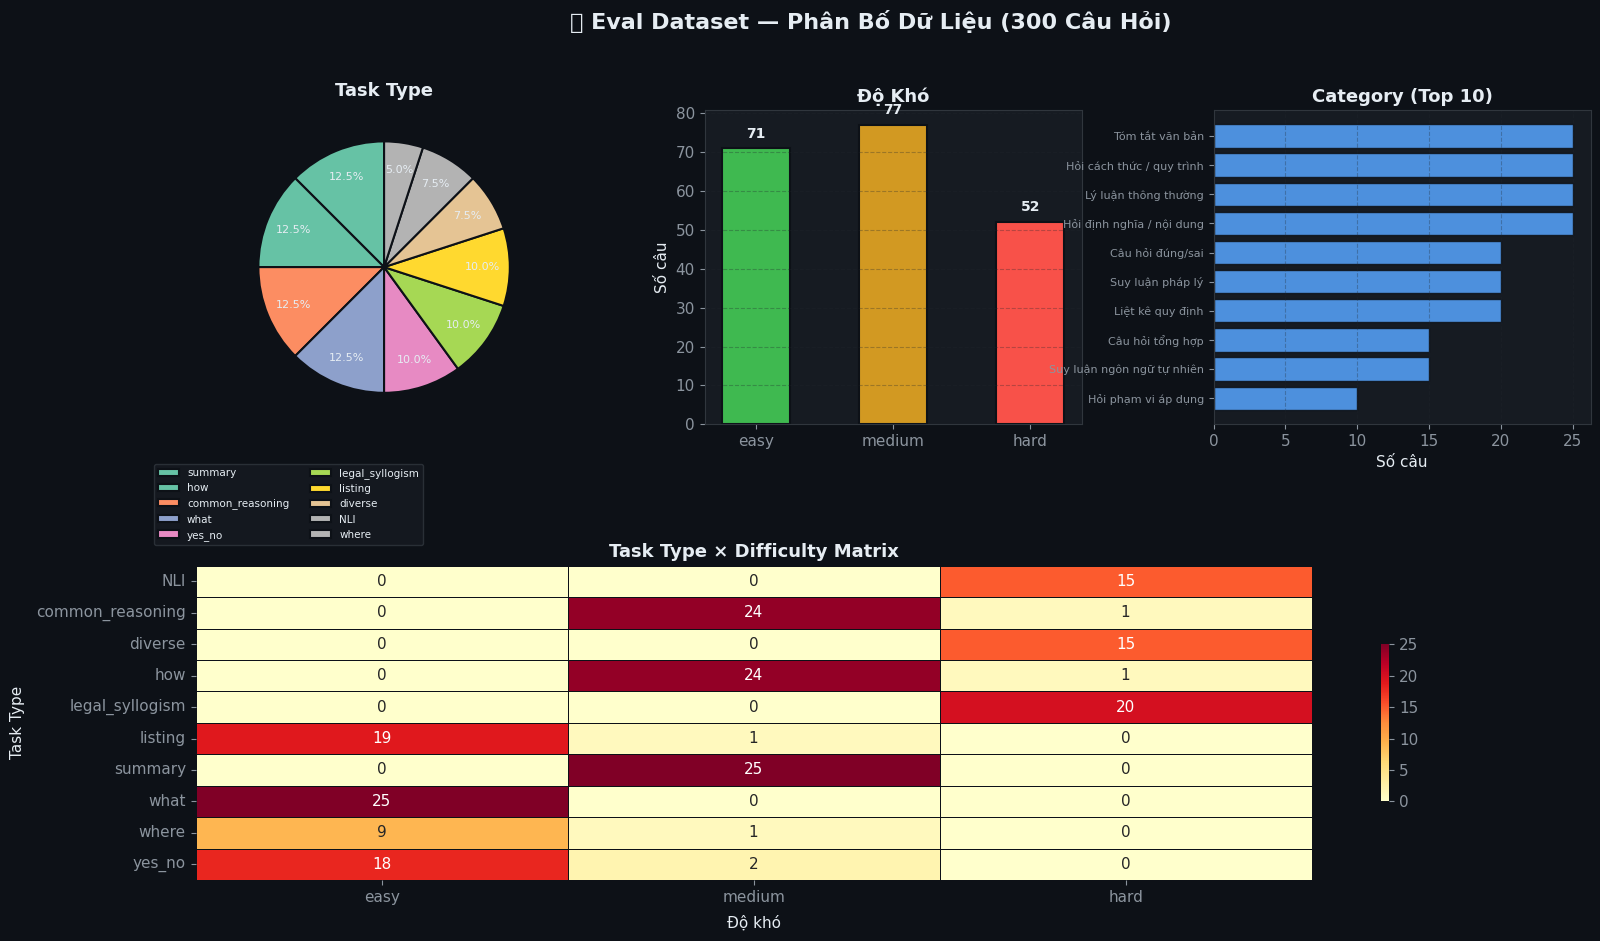

✅ Saved fig1_dataset_distribution.png


In [16]:
# ══════════════════════════════════════════════════════════════
# 4.1 Dataset Distribution Dashboard
# ══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
fig.suptitle('📊 Eval Dataset — Phân Bố Dữ Liệu (300 Câu Hỏi)', 
             fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)

gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) Task Type distribution ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
tt_counts = df_eval['task_type'].value_counts()
colors_tt = plt.cm.Set2(np.linspace(0, 1, len(tt_counts)))
wedges, texts, autotexts = ax1.pie(
    tt_counts.values, labels=None,
    autopct='%1.1f%%', startangle=90,
    colors=colors_tt, pctdistance=0.78,
    wedgeprops={'linewidth': 1.5, 'edgecolor': '#0d1117'}
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('#e6edf3')
ax1.legend(tt_counts.index, loc='lower left', fontsize=7.5,
           bbox_to_anchor=(-0.25, -0.4), ncol=2)
ax1.set_title('Task Type', pad=10)

# ── (B) Difficulty ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
diff_counts = df_eval['difficulty'].value_counts().reindex(['easy', 'medium', 'hard'])
bars = ax2.bar(diff_counts.index, diff_counts.values,
               color=[GREEN, ORANGE, RED], edgecolor='#0d1117',
               linewidth=1.5, width=0.5)
for bar, val in zip(bars, diff_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('Độ Khó')
ax2.set_ylabel('Số câu')
ax2.grid(axis='y', alpha=0.3)
ax2.set_facecolor('#161b22')

# ── (C) Category (top 10) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cat_counts = df_eval['category'].value_counts().head(10)
bars3 = ax3.barh(range(len(cat_counts)), cat_counts.values,
                  color=BLUE, alpha=0.85, edgecolor='#0d1117')
ax3.set_yticks(range(len(cat_counts)))
ax3.set_yticklabels(
    [c[:28]+'…' if len(c) > 28 else c for c in cat_counts.index],
    fontsize=8
)
ax3.set_title('Category (Top 10)')
ax3.set_xlabel('Số câu')
ax3.grid(axis='x', alpha=0.3)
ax3.set_facecolor('#161b22')
ax3.invert_yaxis()

# ── (D) Task type × Difficulty heatmap ───────────────────────
ax4 = fig.add_subplot(gs[1, :])
cross = pd.crosstab(df_eval['task_type'], df_eval['difficulty'])
cross = cross.reindex(columns=['easy', 'medium', 'hard'], fill_value=0)
sns.heatmap(cross, ax=ax4, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'shrink': 0.5})
ax4.set_title('Task Type × Difficulty Matrix')
ax4.set_xlabel('Độ khó', labelpad=8)
ax4.set_ylabel('Task Type', labelpad=8)
ax4.tick_params(axis='x', labelrotation=0)

plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_dataset_distribution.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig1_dataset_distribution.png")

### 4.2 Retrieval Quality Comparison

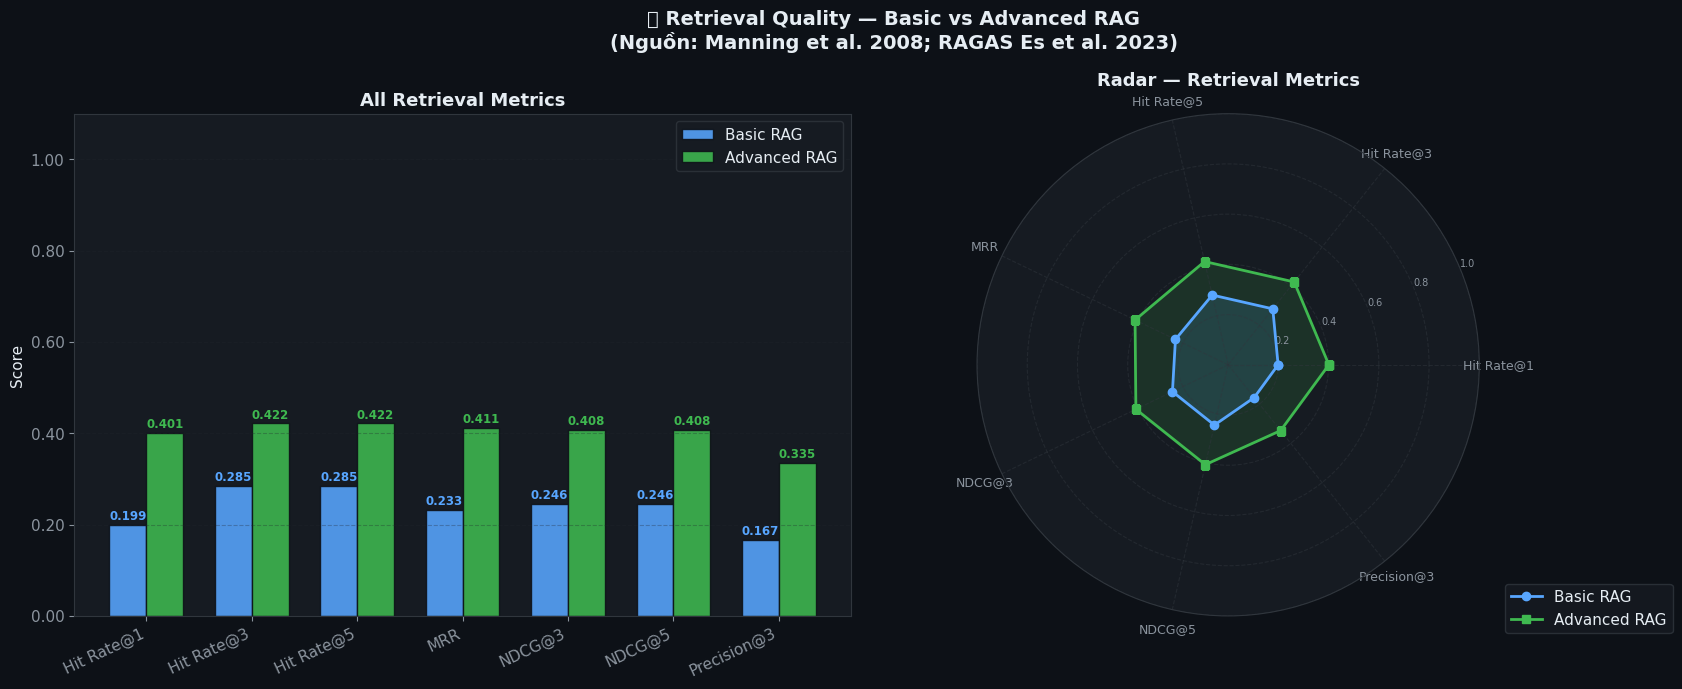

✅ Saved fig2_retrieval_quality.png


In [17]:
# ══════════════════════════════════════════════════════════════
# 4.2 Retrieval Quality — Basic vs Advanced
# ══════════════════════════════════════════════════════════════

retrieval_metrics = [
    ('Hit Rate@1',  'hit_at_1'),
    ('Hit Rate@3',  'hit_at_3'),
    ('Hit Rate@5',  'hit_at_5'),
    ('MRR',         'mrr'),
    ('NDCG@3',      'ndcg_at_3'),
    ('NDCG@5',      'ndcg_at_5'),
    ('Precision@3', 'precision_at_3'),
]

labels  = [m[0] for m in retrieval_metrics]
cols    = [m[1] for m in retrieval_metrics]
b_vals  = [df_basic_ok[c].mean() for c in cols]
a_vals  = [df_adv_ok[c].mean()   for c in cols]

x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0d1117')
fig.suptitle('🔍 Retrieval Quality — Basic vs Advanced RAG\n'
             '(Nguồn: Manning et al. 2008; RAGAS Es et al. 2023)',
             fontsize=14, fontweight='bold', color='#e6edf3')

# ── Left: Grouped bar chart ───────────────────────────────────
ax = axes[0]
ax.set_facecolor('#161b22')
bars_b = ax.bar(x - w/2, b_vals, w, label='Basic RAG',    color=BLUE,  alpha=0.88, edgecolor='#0d1117')
bars_a = ax.bar(x + w/2, a_vals, w, label='Advanced RAG', color=GREEN, alpha=0.88, edgecolor='#0d1117')

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=8.5, color=BLUE, fontweight='bold')
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=8.5, color=GREEN, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('All Retrieval Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# ── Right: Radar chart ────────────────────────────────────────
ax_r = axes[1]
ax_r.set_facecolor('#161b22')

# Use polar
from matplotlib.patches import FancyArrowPatch

num_vars = len(labels)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]  # close loop

b_radar = b_vals + b_vals[:1]
a_radar = a_vals + a_vals[:1]

ax_r.remove()
ax_r = fig.add_subplot(1, 2, 2, polar=True, facecolor='#161b22')
ax_r.set_facecolor('#161b22')

ax_r.plot(angles, b_radar, 'o-', color=BLUE,  linewidth=2, label='Basic RAG')
ax_r.fill(angles, b_radar, alpha=0.15, color=BLUE)
ax_r.plot(angles, a_radar, 's-', color=GREEN, linewidth=2, label='Advanced RAG')
ax_r.fill(angles, a_radar, alpha=0.15, color=GREEN)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(labels, fontsize=9)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_r.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax_r.grid(color='#30363d', alpha=0.5)
ax_r.set_title('Radar — Retrieval Metrics', pad=20)
ax_r.legend(loc='lower right', bbox_to_anchor=(1.4, -0.05))

# Polar styling
ax_r.spines['polar'].set_color('#30363d')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_retrieval_quality.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig2_retrieval_quality.png")

### 4.3 Generation Quality — Faithfulness & Relevancy

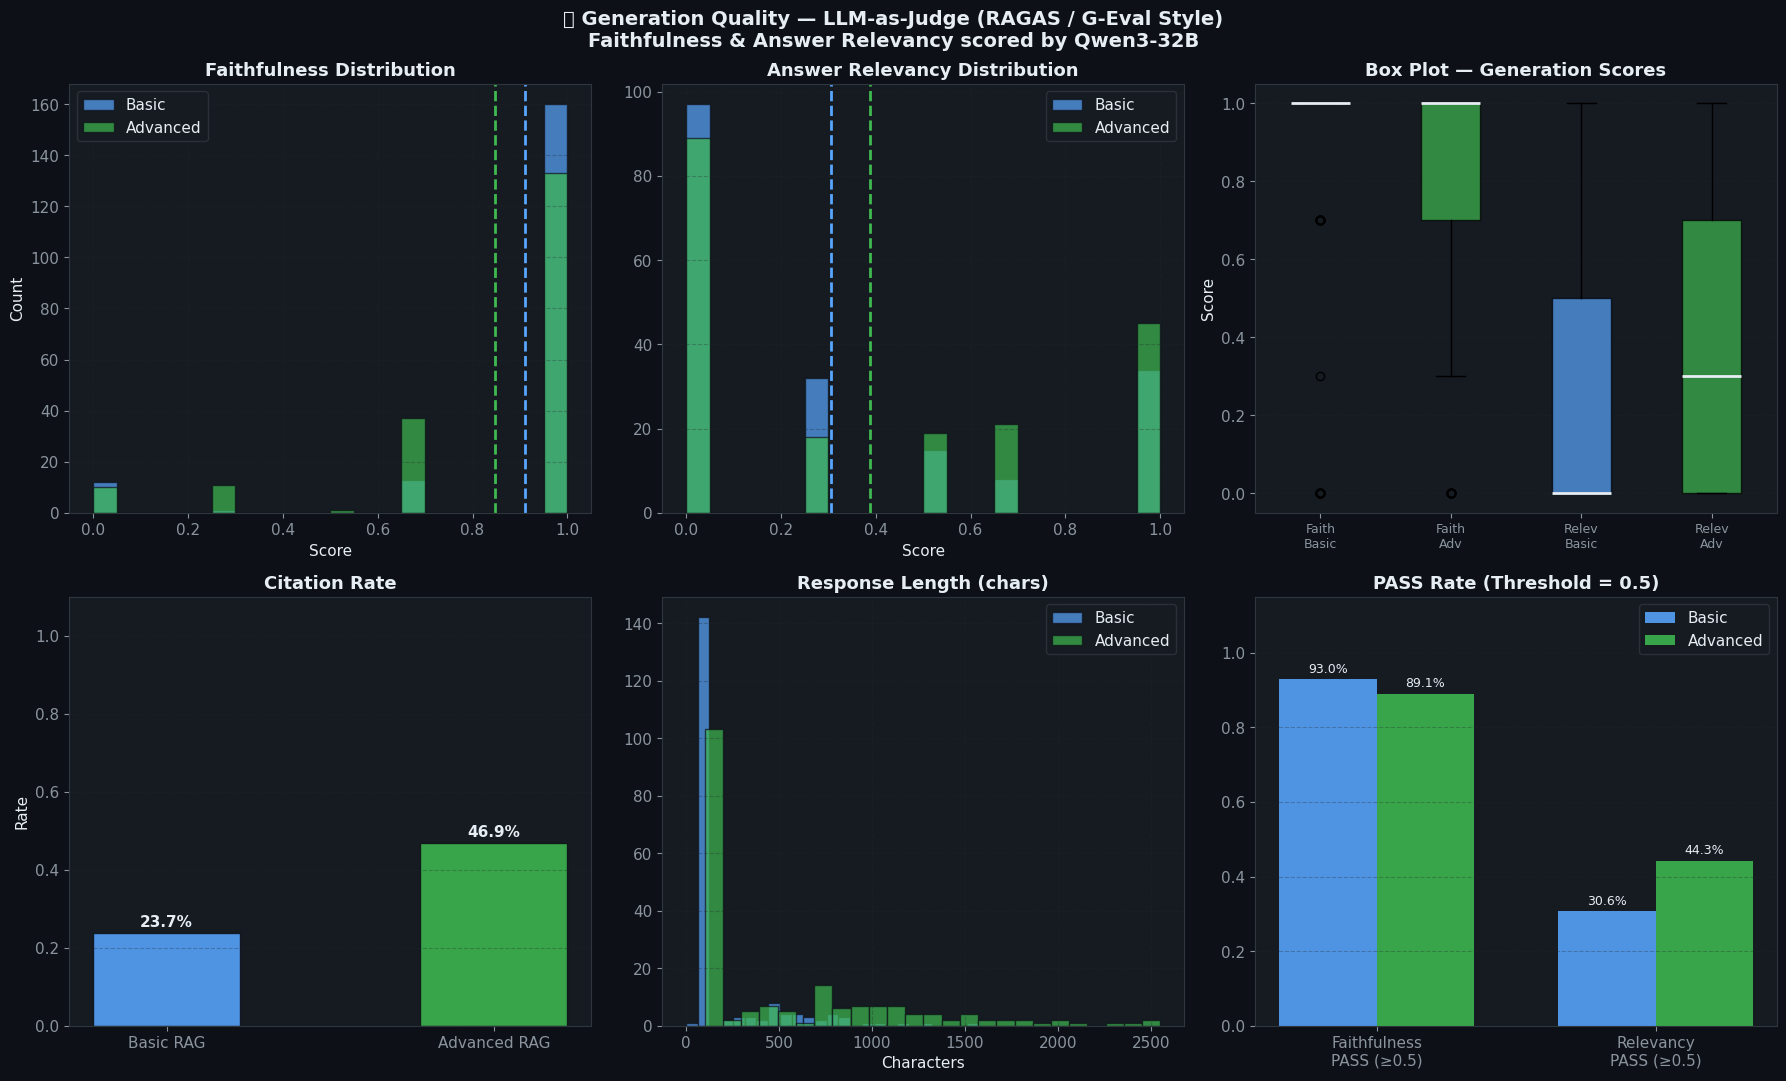

✅ Saved fig3_generation_quality.png


In [18]:
# ══════════════════════════════════════════════════════════════
# 4.3 Generation Quality
# Nguồn: RAGAS (Es et al. 2023), G-Eval (Liu et al. 2023)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor='#0d1117')
fig.suptitle('🤖 Generation Quality — LLM-as-Judge (RAGAS / G-Eval Style)\n'
             'Faithfulness & Answer Relevancy scored by Qwen3-32B',
             fontsize=14, fontweight='bold', color='#e6edf3')

# ── A) Score distribution — Faithfulness ─────────────────────
ax = axes[0][0]
ax.set_facecolor('#161b22')
ax.hist(df_basic_ok['faithfulness'], bins=20, alpha=0.7, color=BLUE,
        label='Basic', edgecolor='#0d1117')
ax.hist(df_adv_ok['faithfulness'],   bins=20, alpha=0.7, color=GREEN,
        label='Advanced', edgecolor='#0d1117')
ax.axvline(df_basic_ok['faithfulness'].mean(), color=BLUE,  ls='--', lw=2)
ax.axvline(df_adv_ok['faithfulness'].mean(),   color=GREEN, ls='--', lw=2)
ax.set_title('Faithfulness Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

# ── B) Score distribution — Relevancy ────────────────────────
ax = axes[0][1]
ax.set_facecolor('#161b22')
ax.hist(df_basic_ok['relevancy'], bins=20, alpha=0.7, color=BLUE,
        label='Basic', edgecolor='#0d1117')
ax.hist(df_adv_ok['relevancy'],   bins=20, alpha=0.7, color=GREEN,
        label='Advanced', edgecolor='#0d1117')
ax.axvline(df_basic_ok['relevancy'].mean(), color=BLUE,  ls='--', lw=2)
ax.axvline(df_adv_ok['relevancy'].mean(),   color=GREEN, ls='--', lw=2)
ax.set_title('Answer Relevancy Distribution')
ax.set_xlabel('Score')
ax.legend()
ax.grid(alpha=0.3)

# ── C) Box plot comparison ─────────────────────────────────────
ax = axes[0][2]
ax.set_facecolor('#161b22')
data_box = [
    df_basic_ok['faithfulness'].dropna(),
    df_adv_ok['faithfulness'].dropna(),
    df_basic_ok['relevancy'].dropna(),
    df_adv_ok['relevancy'].dropna(),
]
bp = ax.boxplot(data_box, patch_artist=True,
                medianprops={'color': '#e6edf3', 'linewidth': 2})
colors_box = [BLUE, GREEN, BLUE, GREEN]
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Faith\nBasic', 'Faith\nAdv', 'Relev\nBasic', 'Relev\nAdv'],
                   fontsize=9)
ax.set_title('Box Plot — Generation Scores')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)

# ── D) Citation Rate ──────────────────────────────────────────
ax = axes[1][0]
ax.set_facecolor('#161b22')
citation_rates = [
    df_basic_ok['has_citation'].mean(),
    df_adv_ok['has_citation'].mean()
]
bars = ax.bar(['Basic RAG', 'Advanced RAG'], citation_rates,
               color=[BLUE, GREEN], alpha=0.88, edgecolor='#0d1117', width=0.45)
for bar, val in zip(bars, citation_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Citation Rate')
ax.set_ylabel('Rate')
ax.grid(axis='y', alpha=0.3)

# ── E) Response length distribution ──────────────────────────
ax = axes[1][1]
ax.set_facecolor('#161b22')
ax.hist(df_basic_ok['response_length'], bins=25, alpha=0.7, color=BLUE,
        label='Basic', edgecolor='#0d1117')
ax.hist(df_adv_ok['response_length'],   bins=25, alpha=0.7, color=GREEN,
        label='Advanced', edgecolor='#0d1117')
ax.set_title('Response Length (chars)')
ax.set_xlabel('Characters')
ax.legend()
ax.grid(alpha=0.3)

# ── F) PASS Rate (threshold = 0.5) ───────────────────────────
ax = axes[1][2]
ax.set_facecolor('#161b22')

def pass_rate(df, metric, threshold=0.5):
    return (df[metric] >= threshold).mean()

metrics_pr = ['faithfulness', 'relevancy']
b_pr = [pass_rate(df_basic_ok, m) for m in metrics_pr]
a_pr = [pass_rate(df_adv_ok,   m) for m in metrics_pr]

x = np.arange(len(metrics_pr))
w = 0.35
bars_b2 = ax.bar(x - w/2, b_pr, w, label='Basic',    color=BLUE,  alpha=0.88)
bars_a2 = ax.bar(x + w/2, a_pr, w, label='Advanced', color=GREEN, alpha=0.88)
for bar in list(bars_b2) + list(bars_a2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['Faithfulness\nPASS (≥0.5)', 'Relevancy\nPASS (≥0.5)'])
ax.set_ylim(0, 1.15)
ax.set_title('PASS Rate (Threshold = 0.5)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_generation_quality.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig3_generation_quality.png")

### 4.4 Efficiency — Latency & Token Usage

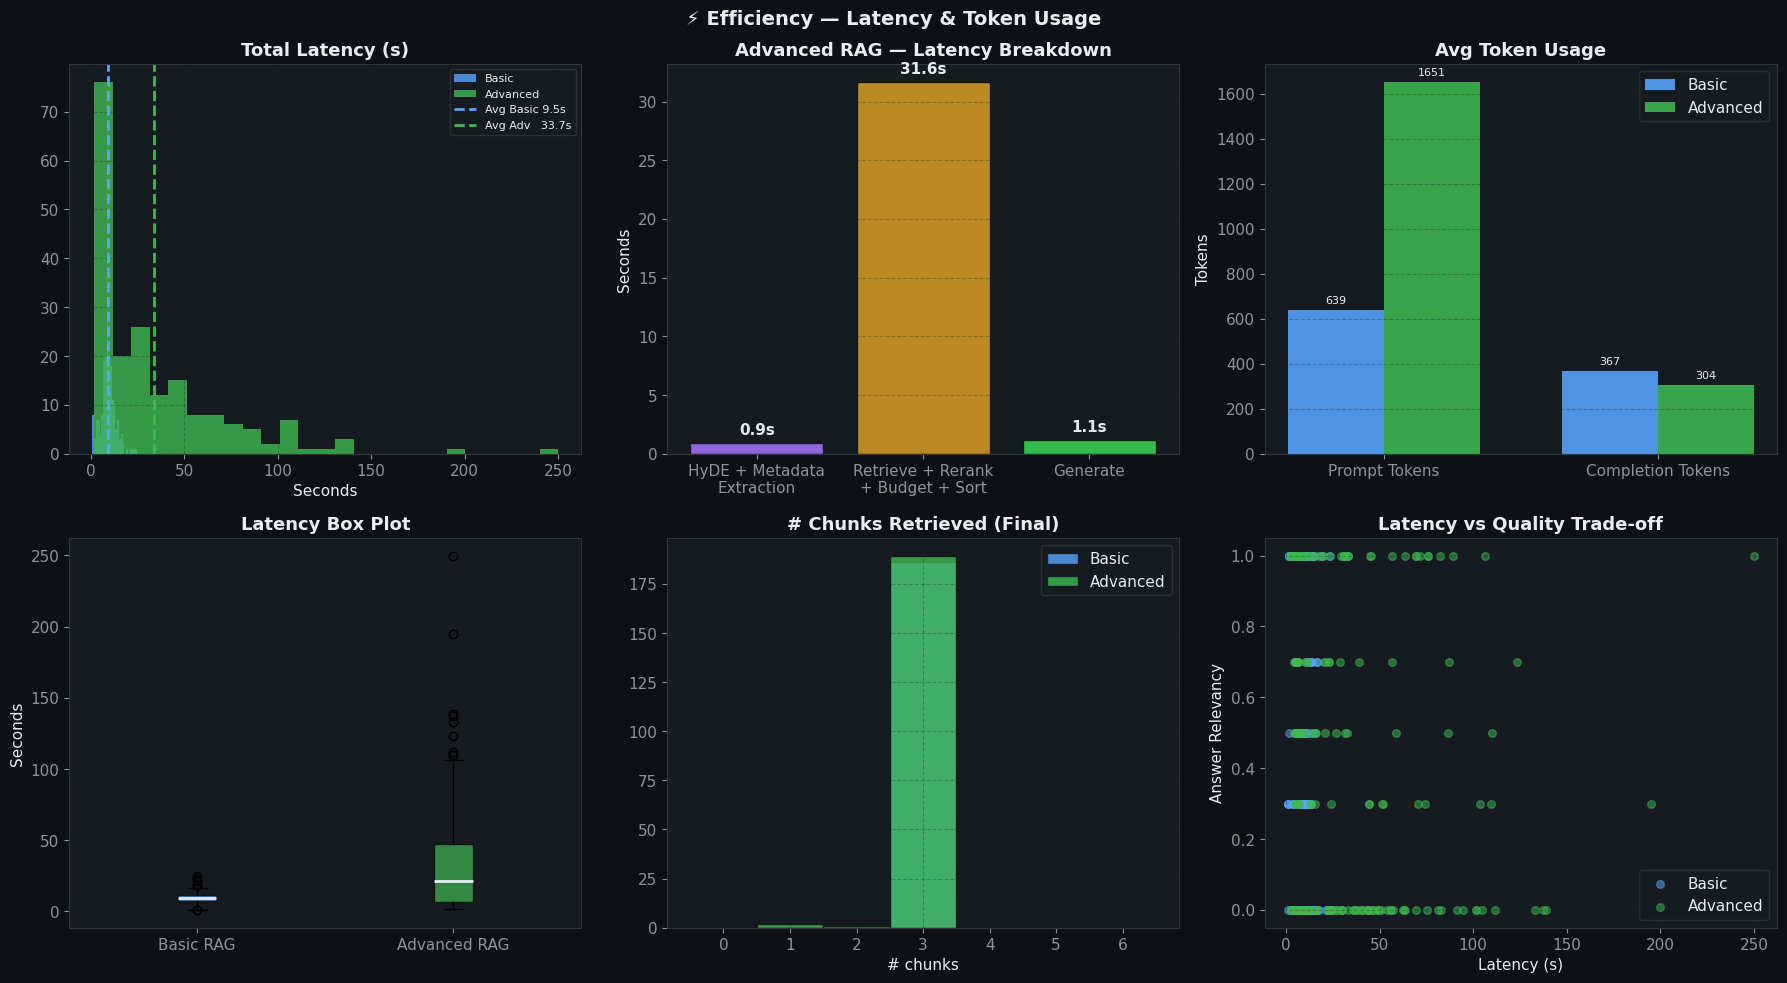

✅ Saved fig4_efficiency.png


In [19]:
# ══════════════════════════════════════════════════════════════
# 4.4 Efficiency Metrics
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#0d1117')
fig.suptitle('⚡ Efficiency — Latency & Token Usage', 
             fontsize=14, fontweight='bold', color='#e6edf3')

# ── A) Total latency distribution ─────────────────────────────
ax = axes[0][0]
ax.set_facecolor('#161b22')
ax.hist(df_basic_ok['latency_total'], bins=25, color=BLUE,  alpha=0.8, label='Basic')
ax.hist(df_adv_ok['latency_total'],   bins=25, color=GREEN, alpha=0.8, label='Advanced')
ax.axvline(df_basic_ok['latency_total'].mean(), color=BLUE,  ls='--', lw=2,
           label=f"Avg Basic {df_basic_ok['latency_total'].mean():.1f}s")
ax.axvline(df_adv_ok['latency_total'].mean(),   color=GREEN, ls='--', lw=2,
           label=f"Avg Adv   {df_adv_ok['latency_total'].mean():.1f}s")
ax.set_title('Total Latency (s)')
ax.set_xlabel('Seconds')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── B) Latency breakdown — Advanced only ─────────────────────
ax = axes[0][1]
ax.set_facecolor('#161b22')
lat_cols = ['latency_hyde', 'latency_retrieve', 'latency_generate']
lat_labels = ['HyDE + Metadata\nExtraction', 'Retrieve + Rerank\n+ Budget + Sort', 'Generate']
lat_means = [df_adv_ok[c].mean() for c in lat_cols]
bars = ax.bar(lat_labels, lat_means,
               color=[PURPLE, ORANGE, TEAL], alpha=0.88, edgecolor='#0d1117')
for bar, val in zip(bars, lat_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}s', ha='center', va='bottom', fontweight='bold')
ax.set_title('Advanced RAG — Latency Breakdown')
ax.set_ylabel('Seconds')
ax.grid(axis='y', alpha=0.3)

# ── C) Token usage comparison ────────────────────────────────
ax = axes[0][2]
ax.set_facecolor('#161b22')
token_data = {
    'Basic RAG'   : [df_basic_ok['tokens_prompt'].mean(),
                     df_basic_ok['tokens_completion'].mean()],
    'Advanced RAG': [df_adv_ok['tokens_prompt'].mean(),
                     df_adv_ok['tokens_completion'].mean()],
}
x = np.arange(2)
w = 0.35
b_tok = ax.bar(x - w/2, token_data['Basic RAG'],    w, label='Basic',    color=BLUE,   alpha=0.88)
a_tok = ax.bar(x + w/2, token_data['Advanced RAG'], w, label='Advanced', color=GREEN,  alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(['Prompt Tokens', 'Completion Tokens'])
ax.set_title('Avg Token Usage')
ax.set_ylabel('Tokens')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in list(b_tok) + list(a_tok):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

# ── D) Box plot latency ───────────────────────────────────────
ax = axes[1][0]
ax.set_facecolor('#161b22')
lat_data = [df_basic_ok['latency_total'].dropna(),
            df_adv_ok['latency_total'].dropna()]
bp = ax.boxplot(lat_data, patch_artist=True,
                medianprops={'color': '#e6edf3', 'linewidth': 2})
for patch, c in zip(bp['boxes'], [BLUE, GREEN]):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Basic RAG', 'Advanced RAG'])
ax.set_title('Latency Box Plot')
ax.set_ylabel('Seconds')
ax.grid(axis='y', alpha=0.3)

# ── E) n_chunks retrieved ─────────────────────────────────────
ax = axes[1][1]
ax.set_facecolor('#161b22')
ax.hist(df_basic_ok['n_chunks'], bins=range(0, 8), alpha=0.8, color=BLUE,
        label='Basic', edgecolor='#0d1117', align='left')
ax.hist(df_adv_ok['n_chunks'],   bins=range(0, 8), alpha=0.8, color=GREEN,
        label='Advanced', edgecolor='#0d1117', align='left')
ax.set_title('# Chunks Retrieved (Final)')
ax.set_xlabel('# chunks')
ax.legend()
ax.grid(alpha=0.3)

# ── F) Latency vs Relevancy scatter ──────────────────────────
ax = axes[1][2]
ax.set_facecolor('#161b22')
ax.scatter(df_basic_ok['latency_total'], df_basic_ok['relevancy'],
           alpha=0.5, color=BLUE,  s=30, label='Basic')
ax.scatter(df_adv_ok['latency_total'],   df_adv_ok['relevancy'],
           alpha=0.5, color=GREEN, s=30, label='Advanced')
ax.set_xlabel('Latency (s)')
ax.set_ylabel('Answer Relevancy')
ax.set_title('Latency vs Quality Trade-off')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_efficiency.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig4_efficiency.png")

### 4.5 Phân tích Theo Task Type & Difficulty

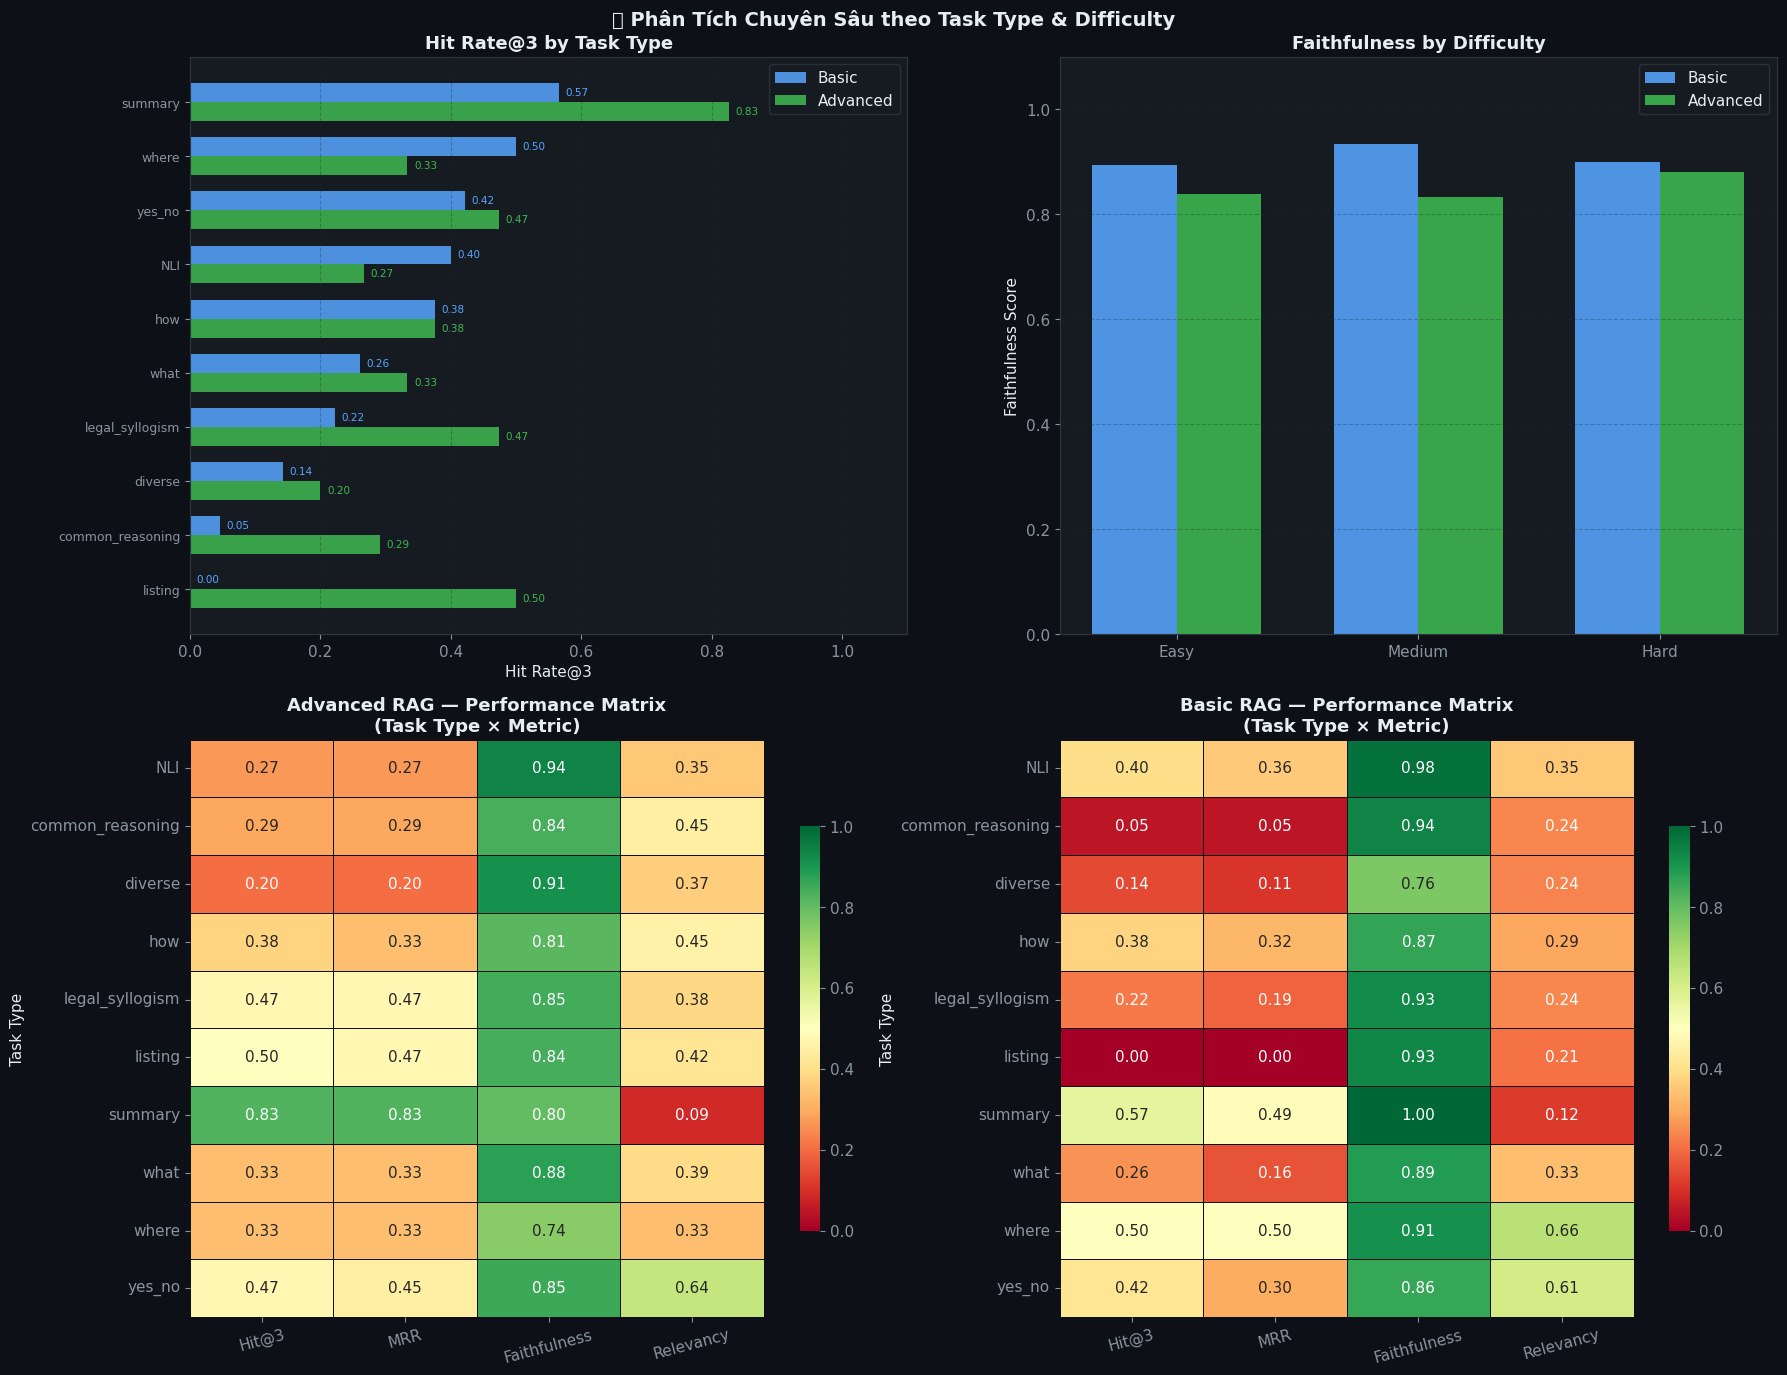

✅ Saved fig5_task_difficulty_analysis.png


In [20]:
# ══════════════════════════════════════════════════════════════
# 4.5 Breakdown by Task Type & Difficulty
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='#0d1117')
fig.suptitle('📑 Phân Tích Chuyên Sâu theo Task Type & Difficulty',
             fontsize=14, fontweight='bold', color='#e6edf3')

# ── A) Hit Rate@3 by task_type ────────────────────────────────
ax = axes[0][0]
ax.set_facecolor('#161b22')

task_b = df_basic_ok.groupby('task_type')['hit_at_3'].mean().sort_values()
task_a = df_adv_ok.groupby('task_type')['hit_at_3'].mean().reindex(task_b.index, fill_value=0)

y = np.arange(len(task_b))
h = 0.35
ax.barh(y + h/2, task_b.values, h, label='Basic',    color=BLUE,  alpha=0.85)
ax.barh(y - h/2, task_a.values, h, label='Advanced', color=GREEN, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(task_b.index, fontsize=9)
ax.set_xlabel('Hit Rate@3')
ax.set_title('Hit Rate@3 by Task Type')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 1.1)
for i, (b, a) in enumerate(zip(task_b.values, task_a.values)):
    ax.text(b + 0.01, i + h/2, f'{b:.2f}', va='center', fontsize=7.5, color=BLUE)
    ax.text(a + 0.01, i - h/2, f'{a:.2f}', va='center', fontsize=7.5, color=GREEN)

# ── B) Faithfulness by difficulty ────────────────────────────
ax = axes[0][1]
ax.set_facecolor('#161b22')

diff_order = ['easy', 'medium', 'hard']
b_faith_diff = df_basic_ok.groupby('difficulty')['faithfulness'].mean().reindex(diff_order)
a_faith_diff = df_adv_ok.groupby('difficulty')['faithfulness'].mean().reindex(diff_order)

x = np.arange(3)
w = 0.35
ax.bar(x - w/2, b_faith_diff.values, w, label='Basic',    color=BLUE,  alpha=0.88)
ax.bar(x + w/2, a_faith_diff.values, w, label='Advanced', color=GREEN, alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(['Easy', 'Medium', 'Hard'])
ax.set_title('Faithfulness by Difficulty')
ax.set_ylabel('Faithfulness Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── C) Heatmap: task_type × metric (Advanced) ─────────────────
ax = axes[1][0]
task_metrics = df_adv_ok.groupby('task_type')[['hit_at_3', 'mrr', 'faithfulness', 'relevancy']].mean()
task_metrics.columns = ['Hit@3', 'MRR', 'Faithfulness', 'Relevancy']
sns.heatmap(task_metrics, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0d1117',
            vmin=0, vmax=1,
            cbar_kws={'shrink': 0.7})
ax.set_title('Advanced RAG — Performance Matrix\n(Task Type × Metric)')
ax.set_ylabel('Task Type')
ax.set_xlabel('')
ax.tick_params(axis='x', labelrotation=15)

# ── D) Heatmap: task_type × metric (Basic) ───────────────────
ax = axes[1][1]
task_metrics_b = df_basic_ok.groupby('task_type')[['hit_at_3', 'mrr', 'faithfulness', 'relevancy']].mean()
task_metrics_b.columns = ['Hit@3', 'MRR', 'Faithfulness', 'Relevancy']
sns.heatmap(task_metrics_b, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0d1117',
            vmin=0, vmax=1,
            cbar_kws={'shrink': 0.7})
ax.set_title('Basic RAG — Performance Matrix\n(Task Type × Metric)')
ax.set_ylabel('Task Type')
ax.set_xlabel('')
ax.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_task_difficulty_analysis.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig5_task_difficulty_analysis.png")

### 4.6 Overall Summary — Radar + Comparison Table

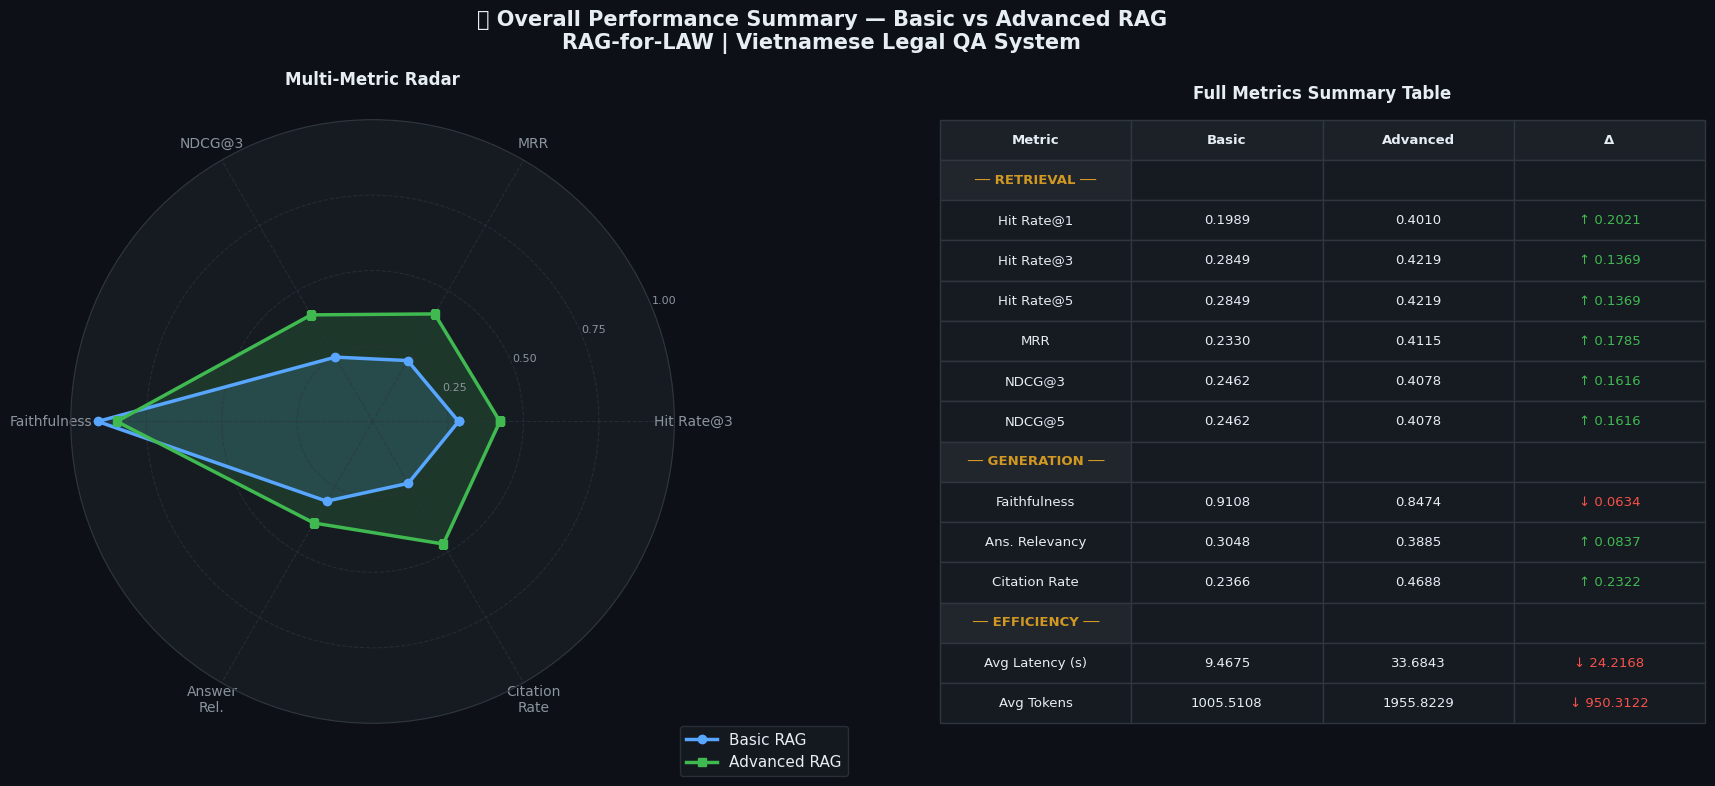

✅ Saved fig6_summary_dashboard.png


In [21]:
# ══════════════════════════════════════════════════════════════
# 4.6 Master Summary Dashboard
# ══════════════════════════════════════════════════════════════

# 6 key metrics normalized to [0,1]
key_metrics = {
    'Hit Rate@3'   : 'hit_at_3',
    'MRR'          : 'mrr',
    'NDCG@3'       : 'ndcg_at_3',
    'Faithfulness' : 'faithfulness',
    'Answer\nRel.' : 'relevancy',
    'Citation\nRate': 'has_citation',
}

km_labels = list(key_metrics.keys())
km_cols   = list(key_metrics.values())

b_km = [df_basic_ok[c].mean() for c in km_cols]
a_km = [df_adv_ok[c].mean()   for c in km_cols]

# Radar
num_vars = len(km_labels)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]
b_radar  = b_km + b_km[:1]
a_radar  = a_km + a_km[:1]

fig = plt.figure(figsize=(18, 8), facecolor='#0d1117')
fig.suptitle('🏆 Overall Performance Summary — Basic vs Advanced RAG\n'
             'RAG-for-LAW | Vietnamese Legal QA System',
             fontsize=15, fontweight='bold', color='#e6edf3')

# ── Left: Radar chart ─────────────────────────────────────────
ax_radar = fig.add_subplot(1, 2, 1, polar=True, facecolor='#161b22')
ax_radar.set_facecolor('#161b22')
ax_radar.plot(angles, b_radar, 'o-', color=BLUE,  linewidth=2.5, label='Basic RAG')
ax_radar.fill(angles, b_radar, alpha=0.18, color=BLUE)
ax_radar.plot(angles, a_radar, 's-', color=GREEN, linewidth=2.5, label='Advanced RAG')
ax_radar.fill(angles, a_radar, alpha=0.18, color=GREEN)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(km_labels, fontsize=10)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=8)
ax_radar.grid(color='#30363d', alpha=0.6)
ax_radar.spines['polar'].set_color('#30363d')
ax_radar.legend(loc='lower right', bbox_to_anchor=(1.3, -0.1), fontsize=11)
ax_radar.set_title('Multi-Metric Radar', pad=25, fontsize=12)

# ── Right: Summary table as styled text ──────────────────────
ax_tbl = fig.add_subplot(1, 2, 2)
ax_tbl.set_facecolor('#0d1117')
ax_tbl.axis('off')

table_data = []
row_cols   = []

sections = [
    ('── RETRIEVAL ──', None),
    ('Hit Rate@1',  ('hit_at_1',  True)),
    ('Hit Rate@3',  ('hit_at_3',  True)),
    ('Hit Rate@5',  ('hit_at_5',  True)),
    ('MRR',         ('mrr',       True)),
    ('NDCG@3',      ('ndcg_at_3', True)),
    ('NDCG@5',      ('ndcg_at_5', True)),
    ('── GENERATION ──', None),
    ('Faithfulness',    ('faithfulness',   True)),
    ('Ans. Relevancy',  ('relevancy',      True)),
    ('Citation Rate',   ('has_citation',   True)),
    ('── EFFICIENCY ──', None),
    ('Avg Latency (s)', ('latency_total',  False)),  # lower is better
    ('Avg Tokens',      ('tokens_total',   False)),
]

cell_text = [['Metric', 'Basic', 'Advanced', 'Δ']]
for name, info in sections:
    if info is None:
        cell_text.append([name, '', '', ''])
    else:
        col, higher_better = info
        b_v = df_basic_ok[col].mean()
        a_v = df_adv_ok[col].mean()
        delta = a_v - b_v
        winner = '↑' if (delta > 0) == higher_better else '↓'
        cell_text.append([
            name,
            f'{b_v:.4f}',
            f'{a_v:.4f}',
            f'{winner} {abs(delta):.4f}'
        ])

tbl = ax_tbl.table(
    cellText=cell_text[1:],
    colLabels=cell_text[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

# Style the table
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#30363d')
    if row == 0:
        cell.set_facecolor('#1c2128')
        cell.set_text_props(color='#e6edf3', fontweight='bold')
    else:
        text = cell.get_text().get_text()
        if '──' in text:
            cell.set_facecolor('#21262d')
            cell.set_text_props(color=ORANGE, fontweight='bold')
        else:
            cell.set_facecolor('#161b22')
            cell.set_text_props(color='#e6edf3')
        if col == 3 and '↑' in text:
            cell.set_text_props(color=GREEN)
        elif col == 3 and '↓' in text:
            cell.set_text_props(color=RED)

ax_tbl.set_title('Full Metrics Summary Table', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig6_summary_dashboard.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig6_summary_dashboard.png")

### 4.7 Error Analysis & Failure Cases

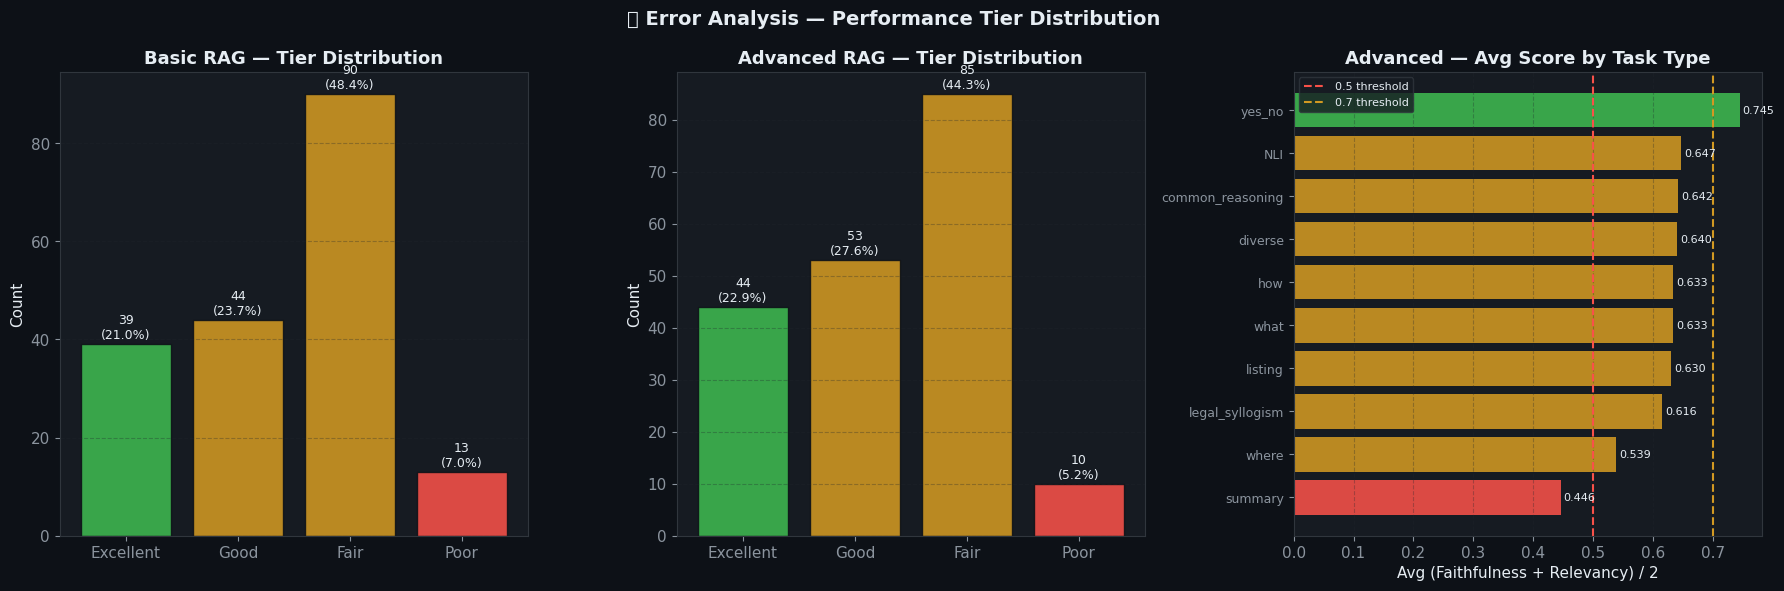

✅ Saved fig7_error_analysis.png


In [22]:
# ══════════════════════════════════════════════════════════════
# 4.7 Error Analysis
# ══════════════════════════════════════════════════════════════

# Phân loại performance tiers
def tier(row):
    score = (row['faithfulness'] + row['relevancy']) / 2
    if score >= 0.8:
        return '🟢 Excellent (≥0.8)'
    elif score >= 0.6:
        return '🟡 Good (0.6–0.8)'
    elif score >= 0.4:
        return '🟠 Fair (0.4–0.6)'
    else:
        return '🔴 Poor (<0.4)'

df_adv_ok['perf_tier'] = df_adv_ok.apply(tier, axis=1)
df_basic_ok['perf_tier'] = df_basic_ok.apply(tier, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')
fig.suptitle('🔍 Error Analysis — Performance Tier Distribution',
             fontsize=14, fontweight='bold', color='#e6edf3')

# ── A) Tier distribution ──────────────────────────────────────
tier_order = ['🟢 Excellent (≥0.8)', '🟡 Good (0.6–0.8)', 
               '🟠 Fair (0.4–0.6)', '🔴 Poor (<0.4)']
tier_colors = [GREEN, ORANGE, '#d29922', RED]

for idx, (df_t, label, ax) in enumerate([
    (df_basic_ok, 'Basic RAG', axes[0]),
    (df_adv_ok,   'Advanced RAG', axes[1])
]):
    ax.set_facecolor('#161b22')
    tier_counts = df_t['perf_tier'].value_counts().reindex(tier_order, fill_value=0)
    short_labels = ['Excellent', 'Good', 'Fair', 'Poor']
    bars = ax.bar(short_labels, tier_counts.values,
                   color=tier_colors, alpha=0.88, edgecolor='#0d1117')
    for bar, val in zip(bars, tier_counts.values):
        pct = val / len(df_t) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{label} — Tier Distribution')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

# ── C) Worst performing task types (Advanced) ─────────────────
ax = axes[2]
ax.set_facecolor('#161b22')
adv_task_score = df_adv_ok.groupby('task_type').apply(
    lambda x: ((x['faithfulness'] + x['relevancy']) / 2).mean()
).sort_values()
colors_task = [RED if v < 0.5 else ORANGE if v < 0.7 else GREEN 
               for v in adv_task_score.values]
ax.barh(range(len(adv_task_score)), adv_task_score.values, 
         color=colors_task, alpha=0.88)
ax.set_yticks(range(len(adv_task_score)))
ax.set_yticklabels(adv_task_score.index, fontsize=9)
ax.axvline(0.5, color=RED,    ls='--', lw=1.5, label='0.5 threshold')
ax.axvline(0.7, color=ORANGE, ls='--', lw=1.5, label='0.7 threshold')
ax.set_title('Advanced — Avg Score by Task Type')
ax.set_xlabel('Avg (Faithfulness + Relevancy) / 2')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(adv_task_score.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig7_error_analysis.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved fig7_error_analysis.png")

## 📝 Section 5: Kết luận & Nhận xét

> Tổng hợp kết quả và so sánh với benchmarks trong literature

In [23]:
# ══════════════════════════════════════════════════════════════
# 5. Final Report — Auto-generated
# ══════════════════════════════════════════════════════════════

now_str = datetime.now().strftime('%Y-%m-%d %H:%M')

def pct(val): return f"{val:.1%}"
def sc(val):  return f"{val:.4f}"

b = summary_basic
a = summary_adv

report = f"""
╔══════════════════════════════════════════════════════════════╗
║         RAG-FOR-LAW — EVALUATION REPORT                     ║
║         Generated: {now_str}                         ║
╚══════════════════════════════════════════════════════════════╝

▶ DATASET
  • Total queries evaluated : {len(eval_data)} câu (300 câu hỏi pháp lý tiếng Việt)
  • Task types              : {df_eval['task_type'].nunique()} loại
  • Difficulty distribution : easy={pct((df_eval['difficulty']=='easy').mean())} | medium={pct((df_eval['difficulty']=='medium').mean())} | hard={pct((df_eval['difficulty']=='hard').mean())}

▶ RETRIEVAL METRICS  
  (Tham chiếu: Manning et al. 2008; RAGAS Es et al. 2023)

  ┌─────────────────┬──────────────┬──────────────┬──────────┐
  │ Metric          │ Basic RAG    │ Advanced RAG │ Δ        │
  ├─────────────────┼──────────────┼──────────────┼──────────┤
  │ Hit Rate@1      │ {sc(b['Hit Rate@1']):^12} │ {sc(a['Hit Rate@1']):^12} │ {'+' if a['Hit Rate@1']>b['Hit Rate@1'] else ''}{sc(a['Hit Rate@1']-b['Hit Rate@1']):^8} │
  │ Hit Rate@3      │ {sc(b['Hit Rate@3']):^12} │ {sc(a['Hit Rate@3']):^12} │ {'+' if a['Hit Rate@3']>b['Hit Rate@3'] else ''}{sc(a['Hit Rate@3']-b['Hit Rate@3']):^8} │
  │ Hit Rate@5      │ {sc(b['Hit Rate@5']):^12} │ {sc(a['Hit Rate@5']):^12} │ {'+' if a['Hit Rate@5']>b['Hit Rate@5'] else ''}{sc(a['Hit Rate@5']-b['Hit Rate@5']):^8} │
  │ MRR             │ {sc(b['MRR']):^12} │ {sc(a['MRR']):^12} │ {'+' if a['MRR']>b['MRR'] else ''}{sc(a['MRR']-b['MRR']):^8} │
  │ NDCG@3          │ {sc(b['NDCG@3']):^12} │ {sc(a['NDCG@3']):^12} │ {'+' if a['NDCG@3']>b['NDCG@3'] else ''}{sc(a['NDCG@3']-b['NDCG@3']):^8} │
  └─────────────────┴──────────────┴──────────────┴──────────┘

▶ GENERATION METRICS  
  (Tham chiếu: RAGAS Es et al. 2023; G-Eval Liu et al. 2023)

  ┌─────────────────┬──────────────┬──────────────┬──────────┐
  │ Metric          │ Basic RAG    │ Advanced RAG │ Δ        │
  ├─────────────────┼──────────────┼──────────────┼──────────┤
  │ Faithfulness    │ {sc(b['Faithfulness']):^12} │ {sc(a['Faithfulness']):^12} │ {'+' if a['Faithfulness']>b['Faithfulness'] else ''}{sc(a['Faithfulness']-b['Faithfulness']):^8} │
  │ Ans. Relevancy  │ {sc(b['Answer Relevancy']):^12} │ {sc(a['Answer Relevancy']):^12} │ {'+' if a['Answer Relevancy']>b['Answer Relevancy'] else ''}{sc(a['Answer Relevancy']-b['Answer Relevancy']):^8} │
  │ Citation Rate   │ {sc(b['Citation Rate']):^12} │ {sc(a['Citation Rate']):^12} │ {'+' if a['Citation Rate']>b['Citation Rate'] else ''}{sc(a['Citation Rate']-b['Citation Rate']):^8} │
  └─────────────────┴──────────────┴──────────────┴──────────┘

▶ EFFICIENCY
  ┌─────────────────┬──────────────┬──────────────┐
  │ Metric          │ Basic RAG    │ Advanced RAG │
  ├─────────────────┼──────────────┼──────────────┤
  │ Avg Latency (s) │ {b['Latency (s)']:.2f}         │ {a['Latency (s)']:.2f}         │
  │ Avg Tokens      │ {b['Tokens Total']:.0f}         │ {a['Tokens Total']:.0f}         │
  └─────────────────┴──────────────┴──────────────┘

▶ SAVED FIGURES
  • fig1_dataset_distribution.png
  • fig2_retrieval_quality.png
  • fig3_generation_quality.png
  • fig4_efficiency.png
  • fig5_task_difficulty_analysis.png
  • fig6_summary_dashboard.png
  • fig7_error_analysis.png
  • results_all.csv

▶ REFERENCES
  [1] Es, S. et al. (2023). RAGAS: Automated Evaluation of Retrieval Augmented Generation.
      arXiv:2309.15217.
  [2] Liu, Y. et al. (2023). G-EVAL: NLG Evaluation using GPT-4 with Better Human Alignment.
      arXiv:2303.16634.
  [3] Manning, C., Raghavan, P., Schütze, H. (2008). Introduction to Information Retrieval.
      Cambridge University Press.
  [4] Gao, L. et al. (2022). Precise Zero-Shot Dense Retrieval without Relevance Labels (HyDE).
      arXiv:2212.10496.
  [5] Liu, N. et al. (2023). Lost in the Middle: How Language Models Use Long Contexts.
      arXiv:2307.03172.
  [6] Thakur, N. et al. (2021). BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of
      IR models. arXiv:2104.08663.
"""

print(report)

# Save report
with open(os.path.join(OUTPUT_DIR, 'evaluation_report.txt'), 'w', encoding='utf-8') as f:
    f.write(report)
print(f"\n✅ Report saved to {OUTPUT_DIR}/evaluation_report.txt")


╔══════════════════════════════════════════════════════════════╗
║         RAG-FOR-LAW — EVALUATION REPORT                     ║
║         Generated: 2026-06-03 23:33                         ║
╚══════════════════════════════════════════════════════════════╝

▶ DATASET
  • Total queries evaluated : 200 câu (300 câu hỏi pháp lý tiếng Việt)
  • Task types              : 10 loại
  • Difficulty distribution : easy=35.5% | medium=38.5% | hard=26.0%

▶ RETRIEVAL METRICS  
  (Tham chiếu: Manning et al. 2008; RAGAS Es et al. 2023)

  ┌─────────────────┬──────────────┬──────────────┬──────────┐
  │ Metric          │ Basic RAG    │ Advanced RAG │ Δ        │
  ├─────────────────┼──────────────┼──────────────┼──────────┤
  │ Hit Rate@1      │    0.1989    │    0.4010    │ + 0.2021  │
  │ Hit Rate@3      │    0.2849    │    0.4219    │ + 0.1369  │
  │ Hit Rate@5      │    0.2849    │    0.4219    │ + 0.1369  │
  │ MRR             │    0.2330    │    0.4115    │ + 0.1785  │
  │ NDCG@3          │    

In [24]:
# ── Xem vài sample câu kém nhất để phân tích ─────────────────
print("=" * 70)
print("TOP 5 WORST CASES — Advanced RAG (Faithfulness + Relevancy thấp nhất)")
print("=" * 70)

df_adv_ok_copy = df_adv_ok.copy()
df_adv_ok_copy['composite'] = (df_adv_ok_copy['faithfulness'] + df_adv_ok_copy['relevancy']) / 2
worst = df_adv_ok_copy.nsmallest(5, 'composite')

for _, row in worst.iterrows():
    print(f"\n[{row['id']}] {row['task_type']} | {row['difficulty']}")
    print(f"Query: {row['query'][:100]}...")
    print(f"Faithfulness: {row['faithfulness']:.3f} — {row['faithfulness_reason'][:80]}")
    print(f"Relevancy   : {row['relevancy']:.3f} — {row['relevancy_reason'][:80]}")
    print(f"Response len: {row['response_length']} chars | Latency: {row['latency_total']:.1f}s")

TOP 5 WORST CASES — Advanced RAG (Faithfulness + Relevancy thấp nhất)

[Q002] summary | medium
Query: Tóm tắt nội dung của Điều 22 Thông tư 13/2018/TT-NHNN kiểm soát nội bộ ngân hàng thương mại chi nhán...
Faithfulness: 0.000 — Câu trả lời hoàn toàn bịa đặt vì không có thông tin về Điều 22 Thông tư 13/2018/
Relevancy   : 0.000 — Hệ thống không cung cấp thông tin liên quan đến Điều 22 Thông tư 13/2018/TT-NHNN
Response len: 192 chars | Latency: 6.0s

[Q008] summary | medium
Query: Tóm tắt nội dung của Điều 14 Thông tư 14/2017/TT-BLĐTBXH xây dựng thẩm định ban hành định mức kinh t...
Faithfulness: 0.000 — Câu trả lời hoàn toàn bịa đặt vì không có thông tin về Điều 14 trong context.
Relevancy   : 0.000 — Hệ thống không tìm thấy thông tin liên quan đến Điều 14 của Thông tư 14/2017/TT-
Response len: 237 chars | Latency: 7.0s

[Q014] where | easy
Query: Việc quy định mã số, tiêu chuẩn chức danh nghề nghiệp và xếp lương cho viên chức chuyên ngành thư vi...
Faithfulness: 0.000 — Câu trả lời hoà